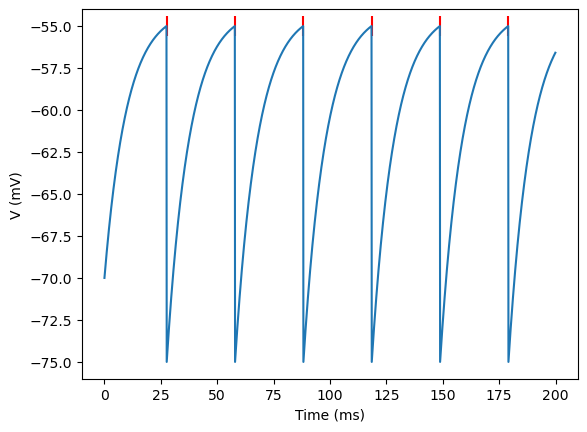

Total spikes: 6


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 파라미터
dt, T = 0.1, 200
tau = 10.0
V_rest, V_th, V_reset = -70, -55, -75
R, I = 10.0, 1.6

n_steps = int(T/dt)

def Euler(I, tau):
    V = np.zeros(n_steps); V[0] = V_rest
    spikes = []
    # TODO: dV/dt = (-(V - V_rest) + R*I) / tau 를 Euler로 풀기
    for t in range(1, n_steps):
        dV = (-(V[t-1] - V_rest)+ R*I)/tau
        V[t] = V[t-1] + dV * dt
        # TODO: V[t]가 V_th 넘으면 spikes에 시각 기록하고 V[t] = V_reset
        if V[t] > V_th:
            spikes.append(t*dt)
            V[t] = V_reset
    return V, spikes

V, spikes = Euler(I, tau)
plt.plot(np.arange(n_steps)*dt, V)
plt.scatter(spikes, [V_th]*len(spikes), color='red', marker='|', s=200)
plt.xlabel("Time (ms)"); plt.ylabel("V (mV)"); plt.show()
print(f"Total spikes: {len(spikes)}")

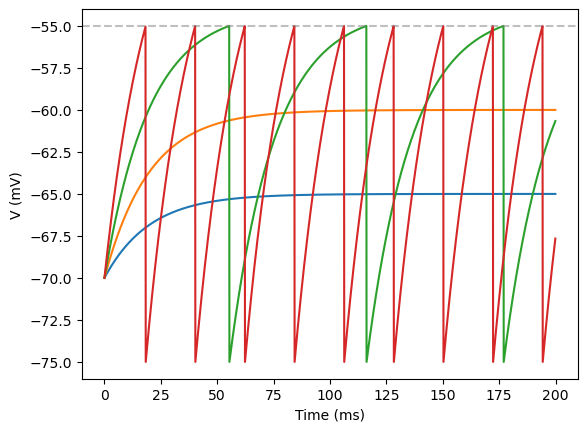

In [21]:
"""
1. 입력 전류 `I`를 0.5, 1.0, 1.6, 2.5 nA로 sweep하며 firing rate(spikes/sec) 곡선 그리기 (F-I curve).
2. `tau`를 5/10/20 ms로 바꿔 발사 빈도 변화 관찰.
3. 시간에 따라 변하는 입력(`I = 1.6 * np.sin(2*np.pi*5*t/1000)`)을 주입해 동기화 시각화.
4. **불응기(refractory period) 2ms** 구현 — 스파이크 직후 일정 시간 V를 reset에 고정.
5. 뉴런 100개를 동시에 시뮬레이션해 raster plot 그리기.
"""

I_list = [0.5, 1.0, 1.6, 2.5]

for I in I_list:
    V, spikes = Euler(I, tau)
    plt.plot(np.arange(n_steps)*dt, V)
plt.axhline(V_th, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Time (ms)"); plt.ylabel("V (mV)")
plt.show()

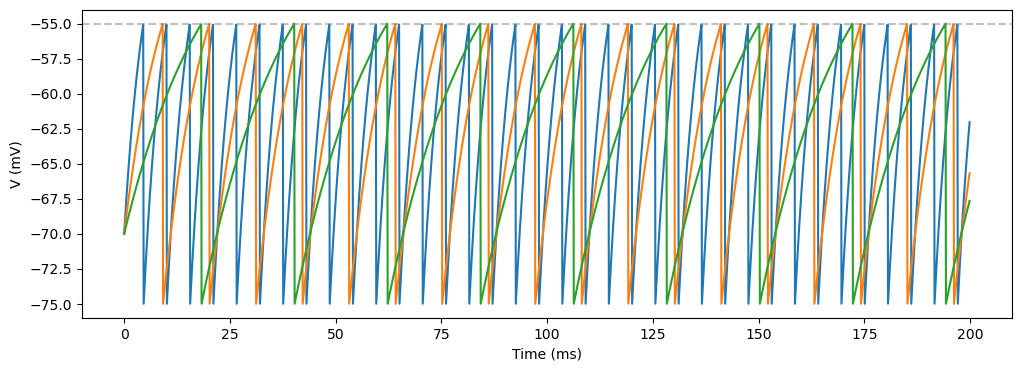

In [19]:
# 2. `tau`를 5/10/20 ms로 바꿔 발사 빈도 변화 관찰.

tau_list = [5., 10., 20.]
plt.figure(figsize=(12, 4))
for tau in tau_list:
    V, spikes = Euler(I, tau)
    plt.plot(np.arange(n_steps)*dt, V)
plt.axhline(V_th, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Time (ms)"); plt.ylabel("V (mV)")
plt.show()

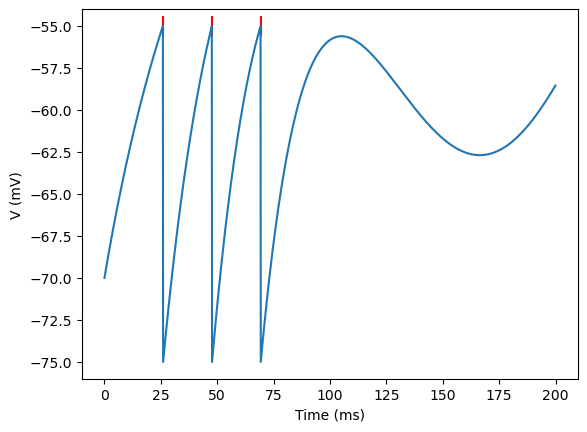

Total spikes: 3


In [22]:
# 3. 시간에 따라 변하는 입력(`I = 1.6 * np.sin(2*np.pi*5*t/1000)`)을 주입해 동기화 시각화.

def Euler_change(I_func, tau):
    V = np.zeros(n_steps)
    V[0] = V_rest
    spikes = []
    
    for t in range(1, n_steps):
        time_ms = t*dt
        dV = (-(V[t-1] - V_rest)+ R*I_func(time_ms))/tau
        V[t] = V[t-1] + dV * dt
        if V[t] > V_th:
            spikes.append(t*dt)
            V[t] = V_reset
    return V, spikes

sin_input = lambda t: 1.6 + 1.0 * np.sin(2*np.pi*5*t/1000)

V, spikes = Euler_change(sin_input, tau)
plt.plot(np.arange(n_steps)*dt, V)
plt.scatter(spikes, [V_th]*len(spikes), color='red', marker='|', s=200)
plt.xlabel("Time (ms)"); plt.ylabel("V (mV)"); plt.show()
print(f"Total spikes: {len(spikes)}")

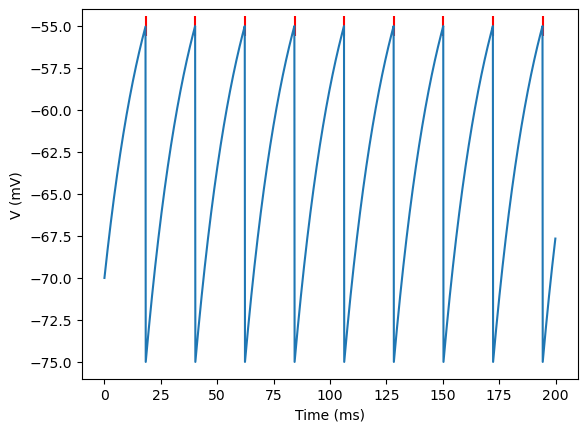

Total spikes: 9


In [24]:
# 4. **불응기(refractory period) 2ms** 구현 — 스파이크 직후 일정 시간 V를 reset에 고정.

def Euler_ref_per(I, tau):
    V = np.zeros(n_steps); V[0] = V_rest
    spikes = []
    cnt = 0
    # TODO: dV/dt = (-(V - V_rest) + R*I) / tau 를 Euler로 풀기
    for t in range(1, n_steps):
        if cnt > 0:
            V[t] = V_reset
            cnt-=1
            continue

        dV = (-(V[t-1] - V_rest)+ R*I)/tau
        V[t] = V[t-1] + dV * dt
        # TODO: V[t]가 V_th 넘으면 spikes에 시각 기록하고 V[t] = V_reset
        if V[t] > V_th:
            spikes.append(t*dt)
            V[t] = V_reset
            cnt = 2
    return V, spikes

V, spikes = Euler(I, tau)
plt.plot(np.arange(n_steps)*dt, V)
plt.scatter(spikes, [V_th]*len(spikes), color='red', marker='|', s=200)
plt.xlabel("Time (ms)"); plt.ylabel("V (mV)"); plt.show()
print(f"Total spikes: {len(spikes)}")

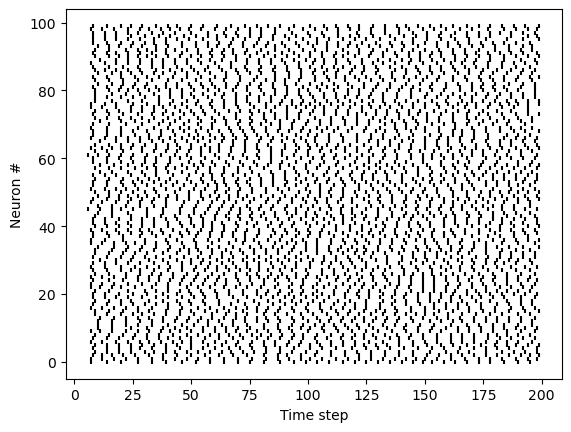

In [30]:
import torch
import norse.torch as norse
import matplotlib.pyplot as plt

seed = 42

# LIF 셀 — 한 줄
lif = norse.LIFCell()

# 입력
torch.manual_seed(seed)
input_current = torch.randn(200, 100) * 0.2 + 0.5   # (T, N)

# 시뮬레이션
state = None
spikes_all = []
for t in range(input_current.shape[0]):
    spike, state = lif(input_current[t], state)
    spikes_all.append(spike)

spikes = torch.stack(spikes_all)

# Raster
times, neurons = torch.where(spikes > 0)
plt.scatter(times, neurons, marker='|', s=5, c='k')
plt.xlabel("Time step"); plt.ylabel("Neuron #")
plt.show()